<u>שמות ט</u>

ויחדלו הקלות והברד ומטר לא נתך ארצה, תלאן ברפיון, **ואימתי ירדו?** בימי יהושע על האמוריים, והשאר עתידין לירד בימי גוג ומגוג (שמות רבה)

$$
\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{v}) = 0
$$

- $\rho$ (kg/m³)
- $t$ (s)
- $\mathbf{v}$ (m/s)


<u>שמות יד</u>

וייט משה את־ידו על־הים **ויולך יי את־הים ברוח קדים עזה כל־הלילה וישם את־הים לחרבה ויבקעו המים**

$$
g = \frac{Gm}{r^2}
$$

- $g$ ($\mathrm{m/s^2}$)
- $G$ ($\mathrm{N\,m^2/kg^2}$)
- $m = 5.972 \times 10^{24}$ kg
- $r = 6.371 \times 10^{6}$ m


$$
x_t = c + \phi x_{t-1} + \varepsilon_t
$$

- $x_t$ (state at $t$)
- $c$ (base)
- $\phi$ (autoregressive coefficient)
- $\varepsilon_t$ (disruption at $t$)


$$
\mu = \frac{c}{1-\phi} \qquad (|\phi|<1)
$$

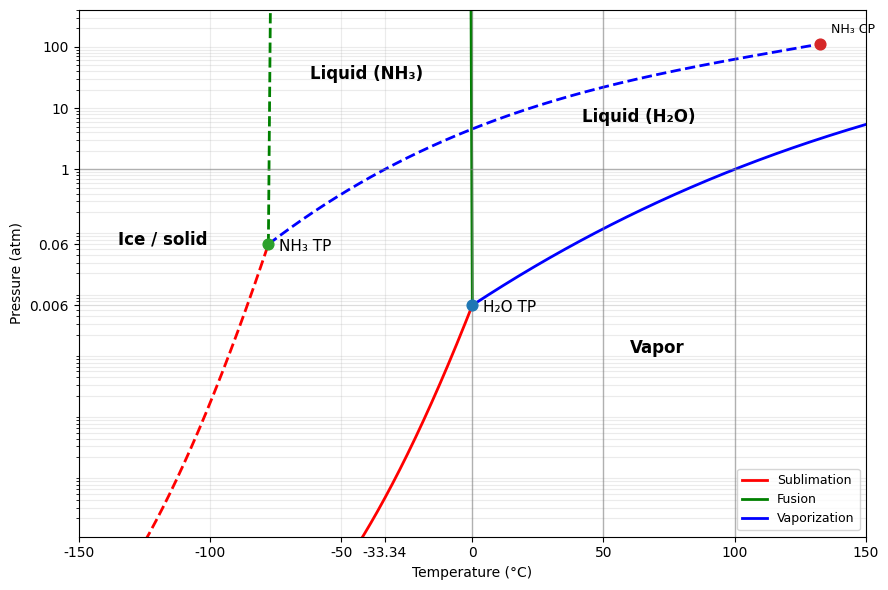

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def fit_vapor_curve(Ttp, Ptp, Tb, Pb, Tc, Pc, slope_at_crit=1.8):
    logPtp, logPb, logPc = np.log10(Ptp), np.log10(Pb), np.log10(Pc)
    x_b = (Tb - Ttp) / (Tc - Ttp)

    a = logPtp
    A = np.array([
        [x_b, x_b**2, x_b**3],
        [1.0, 1.0,    1.0   ],
        [1.0, 2.0,    3.0   ],
    ], dtype=float)
    y = np.array([logPb - a, logPc - a, slope_at_crit], dtype=float)
    b, c, d = np.linalg.solve(A, y)

    def P_of_T(T):
        x = (T - Ttp) / (Tc - Ttp)
        x = np.clip(x, 0.0, 1.0)
        logP = a + b*x + c*x**2 + d*x**3
        return 10**logP

    return P_of_T

def sublimation_curve(T, Ttp, Ptp, Tmin, Pmin=1e-8, shape=1.7):
    x = (T - Tmin) / (Ttp - Tmin)
    x = np.clip(x, 0, 1)
    logP = np.log10(Pmin) + (np.log10(Ptp) - np.log10(Pmin)) * (x**shape)
    return 10**logP


def fusion_curve(P, Ttp, Ptp, dT_dlogP=-0.1):
    P = np.asarray(P, dtype=float)
    return Ttp + dT_dlogP * np.log10(P / Ptp)

H2O = dict(Ttp=0.01,   Ptp=0.00603, Tb=100.0,  Pb=1.0, Tc=374.0, Pc=218.0, Tm=0.0)
NH3 = dict(Ttp=-77.73, Ptp=0.0598,  Tb=-33.34, Pb=1.0, Tc=132.4, Pc=111.0, Tm=-77.73)

substances = {
    "H₂O": {"params": H2O, "ls": "-",  "fusion_dT_dlogP": -0.10, "crit_slope": 1.8},
    "NH₃": {"params": NH3, "ls": "--", "fusion_dT_dlogP": +0.20, "crit_slope": 1.6},
}

boundary_colors = {"sublimation": "red", "fusion": "green", "vaporization": "blue"}

fig, ax = plt.subplots(figsize=(9, 6))

ax.set_xlim(-150, 150)
ax.set_yscale("log")
ax.set_ylim(1e-6, 400)

for name, s in substances.items():
    p = s["params"]
    ls = s["ls"]
    P_vap_func = fit_vapor_curve(
        p["Ttp"], p["Ptp"], p["Tb"], p["Pb"], p["Tc"], p["Pc"],
        slope_at_crit=s["crit_slope"]
    )
    T_vap = np.linspace(p["Ttp"], p["Tc"], 700)
    P_vap = P_vap_func(T_vap)

    Tmin = p["Ttp"] - 90
    T_sub = np.linspace(Tmin, p["Ttp"], 350)
    P_sub = sublimation_curve(
        T_sub, p["Ttp"], p["Ptp"], Tmin, Pmin=1e-8, shape=1.7
    )

    P_fus = np.logspace(np.log10(p["Ptp"]), np.log10(400), 400)
    T_fus = fusion_curve(
        P_fus, p["Ttp"], p["Ptp"], dT_dlogP=s["fusion_dT_dlogP"]
    )

    ax.plot(T_sub, P_sub, color=boundary_colors["sublimation"], ls=ls, lw=2)
    ax.plot(T_fus, P_fus, color=boundary_colors["fusion"],      ls=ls, lw=2)
    ax.plot(T_vap, P_vap, color=boundary_colors["vaporization"], ls=ls, lw=2)

    ax.scatter([p["Ttp"]], [p["Ptp"]], s=60, zorder=6)
    ax.annotate(f"{name} TP", (p["Ttp"], p["Ptp"]), xytext=(8, -5),
                textcoords="offset points", fontsize=11)

    ax.scatter([p["Tc"]], [p["Pc"]], s=60, zorder=6)
    ax.annotate(f"{name} CP", (p["Tc"], p["Pc"]), xytext=(8, 8),
                textcoords="offset points", fontsize=9)

for x in [0, 50, 100]:
    ax.axvline(x, color="gray", lw=1, alpha=0.55)

ax.axhline(1.0, color="gray", lw=1, alpha=0.55)

xticks = [-150, -100, -50, -33.34, 0, 50, 100, 150]
ax.set_xticks(xticks)
ax.set_xticklabels(["-150", "-100", "-50", "-33.34", "0", "50", "100", "150"])

ax.set_yticks([H2O["Ptp"], 0.06, 1.0, 10.0, 100.0])
ax.set_yticklabels([f"{H2O['Ptp']:.3f}", "0.06", "1", "10", "100"])

ax.text(-135, 0.06, "Ice / solid", fontsize=12, fontweight="bold")
ax.text(-62,  30, "Liquid (NH₃)", fontsize=12, fontweight="bold")
ax.text(42,  6, "Liquid (H₂O)", fontsize=12, fontweight="bold")
ax.text(60,   1e-3, "Vapor", fontsize=12, fontweight="bold")

legend_items = [
    Line2D([0],[0], color=boundary_colors["sublimation"], lw=2, label="Sublimation"),
    Line2D([0],[0], color=boundary_colors["fusion"], lw=2, label="Fusion"),
    Line2D([0],[0], color=boundary_colors["vaporization"], lw=2, label="Vaporization"),
]
ax.legend(handles=legend_items, fontsize=9, frameon=True, loc="lower right")

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (atm)")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

וייט משה את־ידו על־הים **ויולך יי את־הים ברוח קדים עזה כל־הלילה וישם את־הים לחרבה ויבקעו המים**

In [5]:
import requests
from IPython.display import Markdown, display

url = f"https://en.wikipedia.org/api/rest_v1/page/summary/McMurdo_Dry_Valleys"
headers = {"User-Agent": "JupyterLabNotebook/1.0 (contact: you@example.com)"}
r = requests.get(url, headers=headers, timeout=20)
data = r.json()
first_para = data.get("extract", "").split("\n")[0]

display(Markdown(first_para))

The McMurdo Dry Valleys are a series of largely snow-free desert valleys on the continental coastline of Victoria Land, Antarctica, east of the East Antarctic Ice Sheet and west of McMurdo Sound and the Ross Sea. The Dry Valleys are notable for being the coldest and driest desert in the world, as well as being the largest ice-free region in Antarctica; as a result, the Valleys have become a notable hotbed for scientific research in the Antarctic region. The Dry Valleys' unique climate is due to their location nestled within the Transantarctic Mountains along with high-pressure katabatic winds that scour away snowfall and humidity across the region. Surrounding mountains prevent the flow of ice from nearby glaciers. The region's geology is primarily granites and gneisses, and glacial tills dot the bedrock landscape, with loose gravel covering the ground. The Valleys are one of the driest places on Earth, though there are several anecdotal accounts of rainfall within the Dry Valleys.

In [1]:
from IPython.display import Image, display
display(Image(url="https://astrobiology.com/wp-content/uploads/2022/12/Permafrost-work-in-the-Dry-Valleys-scaled.jpg"))

<u>שמות כ</u>

וידבר '' את **כל**-הדברים האלה לאמר


את כל הדברים האלה. מלמד שאמר הקב"ה עשרת הדברות **בדבור אחד, מה שאי אפשר לאדם לומר כן**, אם כן מה ת"ל עוד אנכי ולא יהיה לך? שחזר ופרש על כל דבור ודבור בפני עצמו (שם): (רש"י)

In [10]:
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed

gematria = {
    1: "א",  2: "ב",  3: "ג",  4: "ד",  5: "ה",  6: "ו",  7: "ז",  8: "ח",  9: "ט",
    10: "י", 20: "כ", 30: "ל", 40: "מ", 50: "נ", 60: "ס", 70: "ע", 80: "פ", 90: "צ",
    100: "ק", 200: "ר", 300: "ש", 400: "ת",
}
sofit = {20: "ך", 40: "ם", 50: "ן", 80: "ף", 90: "ץ"}

dibrot = [
    "1 50 20 10",
    "30 1  10 5 10 5",
    "30 1  400 300 1",
    "7 20 6 200",
    "20 2 4",
    "30 1  400 200 90 8",
    "30 1  400 50 1 80",
    "30 1  400 3 50 2",
    "30 1  400 70 50 5",
    "30 1  400 8 40 4",
]

count = {i: gematria[i] for i in range(1, 10)}
count[10] = gematria[10]  # י

def decode_and_stream(numeric_phrase: str) -> None:
    words = [w for w in numeric_phrase.strip().split("  ") if w]
    decoded_words = []
    for w in words:
        nums = [int(tok) for tok in w.split()]
        letters = [gematria[n] for n in nums]
        if nums and nums[-1] in sofit:
            letters[-1] = sofit[nums[-1]]
        decoded_words.append("".join(letters))

    rtl_stream = " ".join(word[::-1] for word in decoded_words[::-1])

    for ch in rtl_stream:
        sys.stdout.write(ch)
        sys.stdout.flush()

def stream_prefix(i: int) -> None:
    for ch in (count[i] + " "):
        sys.stdout.write(ch)
        sys.stdout.flush()

In [11]:
for i, item in enumerate(dibrot, start=1):
    stream_prefix(i)
    decode_and_stream(item)
    for ch in "  ":
        sys.stdout.write(ch)
        sys.stdout.flush()
sys.stdout.write("\n")
sys.stdout.flush()

א יכנא  ב היהי אל  ג אשת אל  ד רוכז  ה דבכ  ו חצרת אל  ז ףאנת אל  ח בנגת אל  ט הנעת אל  י דמחת אל  


In [14]:
def worker(i: int, item: str) -> None:
    stream_prefix(i)
    decode_and_stream(item)
    for ch in "  ":
        sys.stdout.write(ch)
        sys.stdout.flush()

with ThreadPoolExecutor(max_workers=10) as ex:
    futures = [ex.submit(worker, i, item) for i, item in enumerate(dibrot, start=1)]
    for f in as_completed(futures):
        f.result()

sys.stdout.write("\n")
sys.stdout.flush()

א יכנאב ג   אהשיתהי  אד אלרל   והכ  זד  בכ  וזחט   בחהנצנערגתתת   אאאלל  ל   י  דמחת אל   ףאנת 

אל  
